# NB2 — OddSHAP paper reproduction with the **author's improvement (PR #560)**

This notebook reproduces the paper's results (Fumagalli et al. 2026, *An Odd Estimator
for Shapley Values*, arXiv:2602.01399) using the paper author's follow-up **PR #560**
(relaxed minimum budget + paired-row sampling). Every figure names its value function, dimension,
and the OddSHAP variant, and carries an experimental-environment banner.

> **Note on NB1 vs NB2.** NB1 and NB2 share the *same* code, parameterised by one
> variant switch (`ODDSHAP_VARIANT`): NB1 = `v522_merged` (ours), NB2 = `v560_improved`
> (the author's PR #560). They are structurally identical by design; NB3 shows the two
> produce the same paper-scale numbers.

**Provenance.** All numbers are produced by the cluster scripts in `notebooks/oddshap/cluster/`
and written to the committed `notebooks/oddshap/data/` folder; this notebook reads them and
plots. Regenerate with `bash notebooks/oddshap/cluster/submit_all.sh v560_improved`.

**Value function** (paper Table 2): XGBoost + interventional perturbation, 50 background
samples; ground truth = exact interventional TreeSHAP (tabular) / exact enumeration (GPU).

**Accessibility.** Colours are Okabe-Ito (colour-blind-safe) and every series also carries
a distinct marker and line style, so figures read in greyscale and under any colour vision.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

for _cand in (Path.cwd(), Path.cwd() / "notebooks" / "oddshap", Path.cwd().parent):
    if (_cand / "core" / "report.py").exists():
        sys.path.insert(0, str(_cand))
        break
from core import report as R
from core.constants import ESTIMATORS, GPU_VF_NAMES, TABULAR_VF_NAMES

VARIANT = os.environ.get("ODDSHAP_VARIANT", "v560_improved")
TAB_VFS, GPU_VFS = TABULAR_VF_NAMES, GPU_VF_NAMES
BANNER_TAB = R.environment_banner(VARIANT, gt="exact interventional TreeSHAP")
BANNER_GPU = R.environment_banner(
    VARIANT,
    gt="exact Shapley (2^d enumeration)",
    vf_family="deep model (ViT16 / DistilBERT), baseline imputation",
)
print(R.experiment_setup(VARIANT))
_missing = [vf for vf in TAB_VFS + GPU_VFS if not R.has(f"table1_{vf}_{VARIANT}.csv")]
print(
    "  Data completeness   :",
    "all value functions present"
    if not _missing
    else f"MISSING {_missing} — run the cluster scripts to fill",
)

========================  EXPERIMENTAL SETUP  ========================
  OddSHAP variant     : OddSHAP PR #560 (author improvement)
  Instances / VF      : N = 30   (every median / IQR band / mean / std is over these 30)
  Tabular VFs (6)     : cancer (d=30), realestate (d=15), corrgroups60 (d=60), independentlinear60 (d=60), nhanes (d=79), crime (d=101)
  Deep-learning VFs (2) : vit16 (d=16), distilbert (d=14)
  Estimators (7)       : MSR, SVARM, PermSamp, KernelSHAP, kADDSHAP, RegressionMSR, OddSHAP
  Value function      : XGBoost + interventional imputation, 50 background samples [tabular];
                        ViT16 / DistilBERT class probability [deep-learning]
  Ground truth        : exact interventional TreeSHAP [tabular];  exact 2^d enumeration [deep-learning]
  Metric              : single-feature Shapley MSE vs ground truth, aggregated over the N instances
  Table 1 / 3 budget  : m = max(d+1, 100*d)
  Figure 2 budgets    : log-spaced grid, m = d+1 .. min(2^d, 20000)
  Figu

## Table 1 — average rank (headline result)

Median MSE at budget ≈ 100·d; each estimator's average rank across value functions is the
paper's headline. OddSHAP (highlighted) reproduces rank-1.

Average rank over 8 value functions ['cancer', 'realestate', 'corrgroups60', 'independentlinear60', 'nhanes', 'crime', 'vit16', 'distilbert']:
  OddSHAP         1.12
  kADDSHAP        2.75
  RegressionMSR   3.25
  PermSamp        4.12
  KernelSHAP      4.25
  SVARM           5.62
  MSR             6.88


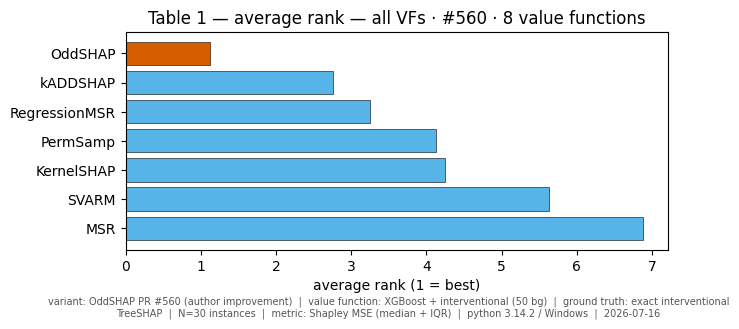

In [2]:
avg_rank, used = R.average_rank(TAB_VFS + GPU_VFS, VARIANT)
if avg_rank:
    ordered = sorted(avg_rank, key=avg_rank.get)
    print(f"Average rank over {len(used)} value functions {used}:")
    for e in ordered:
        print(f"  {e:<15} {avg_rank[e]:.2f}")
    fig, ax = plt.subplots(figsize=(7, 3.3))
    colors = (
        [R.ODDSHAP_COLOR if e == "OddSHAP" else R.OKABE_ITO["sky"] for e in ordered]
        if hasattr(R, "OKABE_ITO")
        else [R.estimator_style(e)["color"] for e in ordered]
    )
    ax.barh(ordered, [avg_rank[e] for e in ordered], color=colors, edgecolor="black", lw=0.4)
    ax.invert_yaxis()
    ax.set_xlabel("average rank (1 = best)")
    ax.set_title(
        R.fig_title("Table 1 — average rank", "all VFs", VARIANT, f"{len(used)} value functions")
    )
    R.add_banner(fig, BANNER_TAB)
    plt.show()

## Table 3 — summary statistics (median, mean, **std**, Q1, Q3)

The paper's Table 3 reports mean / median / Q1 / Q3 per estimator and value function. We
reproduce that layout and **additionally report the standard deviation (std)** — the paper's
table omits it, but it is requested for our write-up. One block of rows per estimator
(OddSHAP first); one column per value function.

In [3]:
tbl = R.table3_dataframe(TAB_VFS + GPU_VFS, VARIANT)
try:
    display(
        tbl.style.set_caption(
            f"Table 3 — summary statistics of Shapley MSE (median / mean / std / Q1 / Q3) · "
            f"{R.VARIANT_LABEL[VARIANT]}"
        )
    )
except (NameError, AttributeError):
    print(tbl)

## Figure 2 — MSE vs budget (per value function)

One **row per value function**, three panels each — all showing median ± IQR band, colours
aligned with the paper (plus a redundant marker + line style, so the panels stay readable
under colour vision deficiency):

1. **Ours** — our reproduction: every estimator we run, median line + IQR band.
2. **Paper** — the paper's Figure-2 medians, *redrawn* from the digitised coordinates as a
   real axes (so it renders at exactly the same size as panels 1/3 with real ticks/labels;
   the authentic paper image lives in `paper_reference/`). Full paper method set including
   LeverageSHAP / 3-PolySHAP / Proxy, which we do not run. Per-method IQR bands were not
   digitised (only OddSHAP's); the medians + OddSHAP band carry the comparison.
3. **OddSHAP: ours vs paper** — OddSHAP alone, our curve + IQR band (solid) over the paper's
   median curve (dashed; the paper's per-curve band edges were not digitised), so the
   reproduction fidelity is visible at a glance.

> **kADDSHAP low-budget divergence (a finding, shown not hidden).** On the high-dimensional
> value functions (d ≥ 60) the k-additive regression's normal-equations solve goes near-singular
> at the smallest budgets and returns a diverged estimate (MSE up to 1e94, crime). We keep these
> points: panel (1)'s y-axis is focused on the real estimates so the diverged line visibly shoots
> off the top edge, with an annotation of the value. This is the regression-path sibling of the
> TreeSHAP Chebyshev-Vandermonde instability we fixed upstream (PR #547) — `np.linalg.solve` on a
> near-singular normal matrix returns garbage instead of raising. The paper's Figure 2 includes
> neither kADDSHAP nor KernelSHAP — those are extra baselines we add.

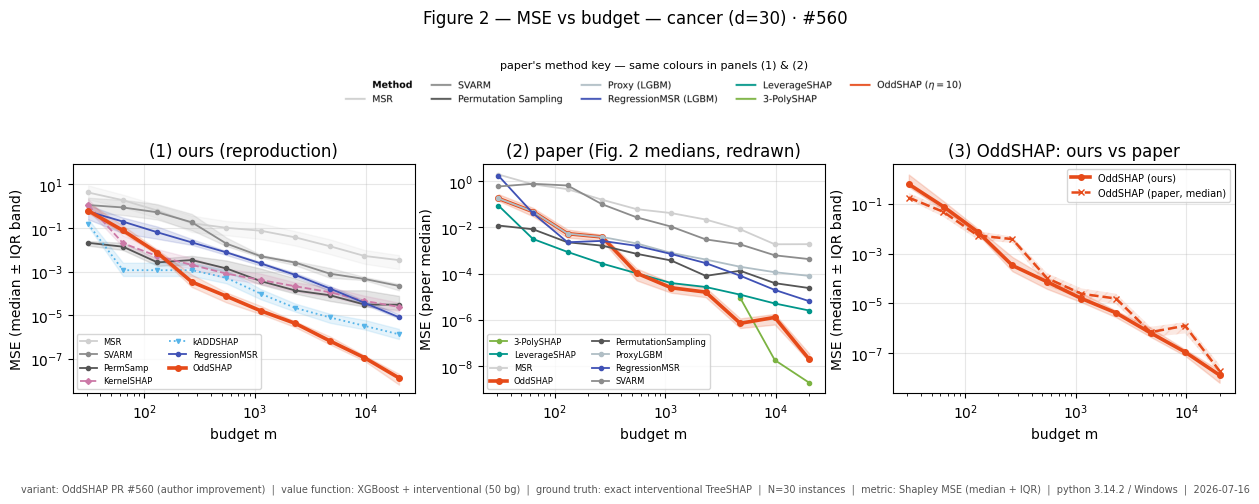

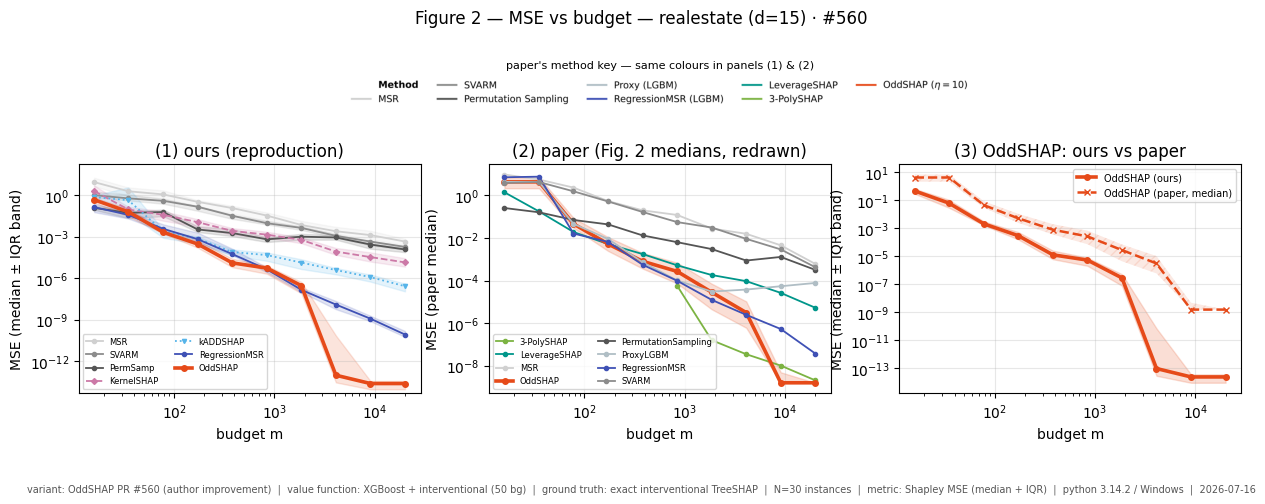

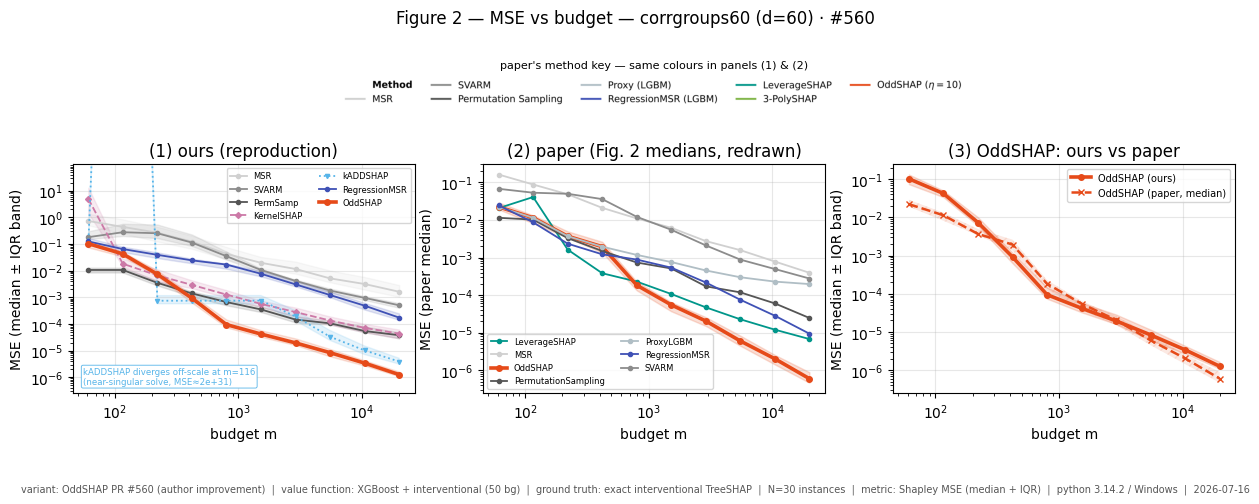

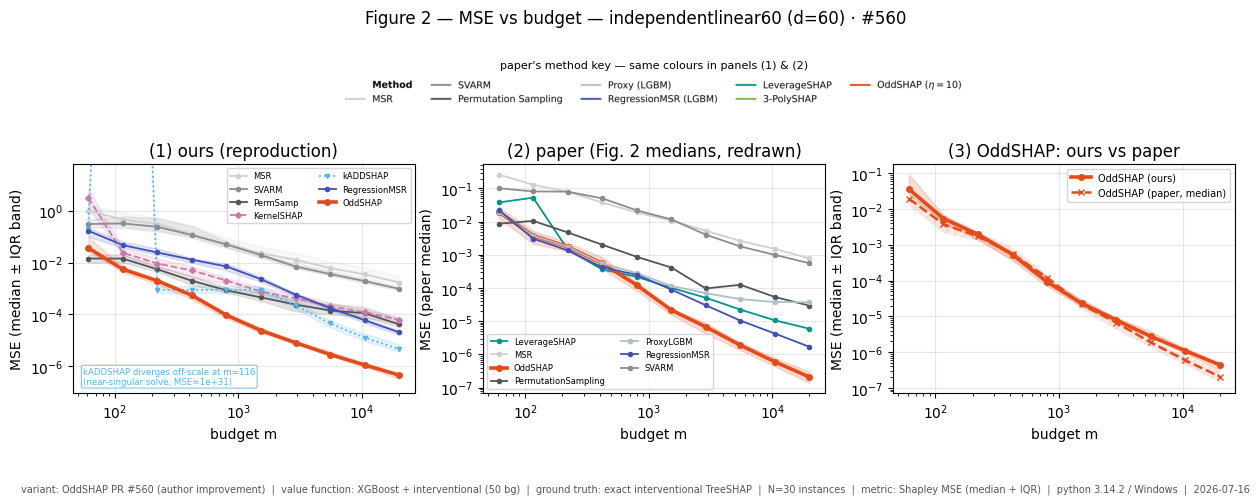

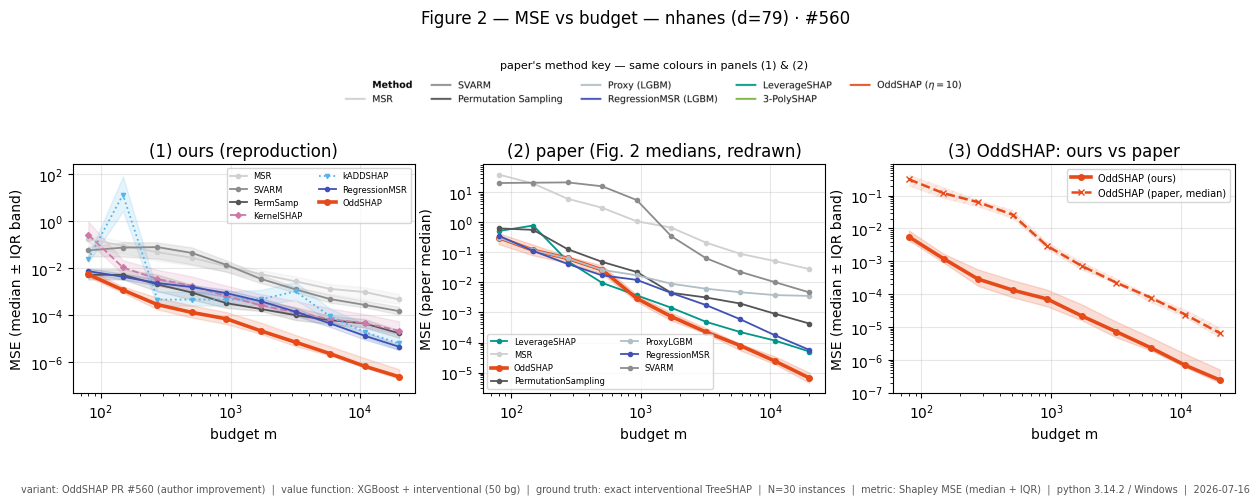

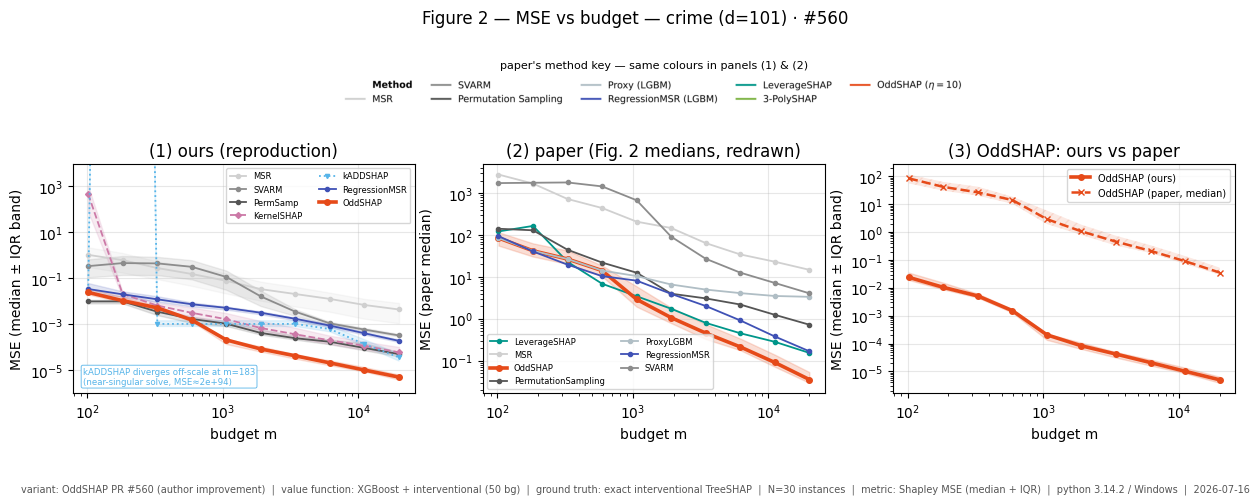

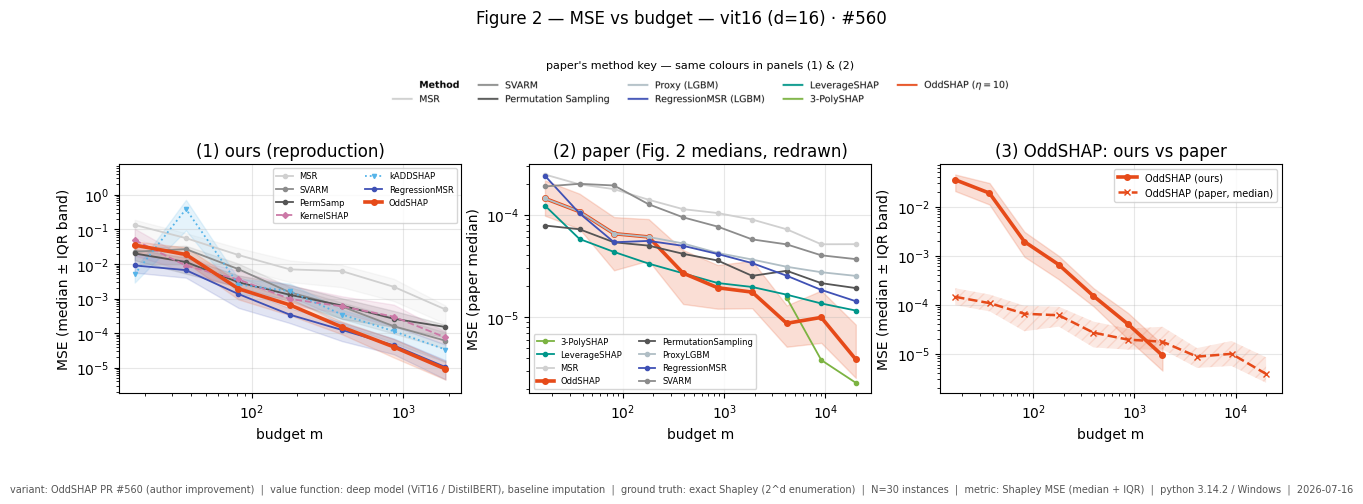

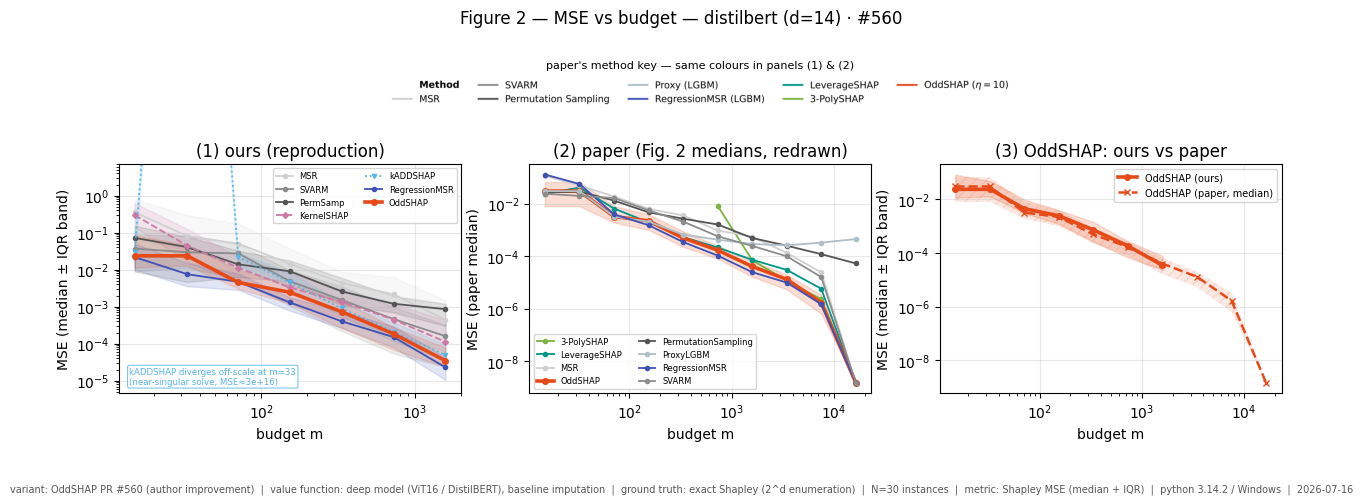

In [4]:
import matplotlib.image as mpimg

for vf in TAB_VFS + GPU_VFS:  # all 8 value functions
    ours = R.load_fig2(vf, VARIANT)
    paper = R.load_paper_fig2(vf)
    png = R.paper_figure_path(vf, "fig2")
    band = R.load_paper_oddshap_band(vf)  # digitised paper OddSHAP band, if available
    if not ours:
        continue
    is_gpu = vf in GPU_VFS
    banner = BANNER_GPU if is_gpu else BANNER_TAB
    # paper's own method key on top: the extracted per-VF paper panel has no legend of its
    # own (the paper shares one legend across sub-plots), and its colours match our panel (1),
    # so this single strip labels both panels 1 and 2.
    fig = plt.figure(figsize=(15, 4.8))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 7], hspace=0.42)
    axl = fig.add_subplot(gs[0, :])
    axl.axis("off")
    _leg = R.paper_legend_path()
    if _leg is not None:
        axl.imshow(mpimg.imread(str(_leg)))
        axl.set_title("paper's method key — same colours in panels (1) & (2)", fontsize=8)
    axes = [fig.add_subplot(gs[1, j]) for j in range(3)]

    # (1) ours — median + IQR band. Diverged points (kADDSHAP's near-singular low-budget
    # solve, MSE up to 1e94) are NOT hidden: they shoot off the top of the axis and are
    # annotated, because the divergence is itself a finding.
    ax = axes[0]
    finite_meds, diverged = [], []
    for e in ESTIMATORS:
        pts = sorted(ours.get(e, {}).items())
        if not pts:
            continue
        xs = [b for b, _ in pts]
        med = np.array([v[0] for _, v in pts])
        q1 = np.array([v[1] for _, v in pts])
        q3 = np.array([v[2] for _, v in pts])
        st = R.paper_style(e)
        ax.plot(xs, np.clip(med, 1e-32, None), label=e, **st)
        ax.fill_between(
            xs, np.clip(q1, 1e-32, None), np.clip(q3, 1e-32, None), color=st["color"], alpha=0.15
        )
        finite_meds += [m for m in med if np.isfinite(m) and m <= R.DIVERGED_MSE]
        diverged += [(e, b, m) for b, m in zip(xs, med) if m > R.DIVERGED_MSE]
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    # focus the y-axis on the real estimates so the readable curves are not crushed by the
    # off-scale divergence; the diverged line still visibly shoots past the top edge.
    if finite_meds:
        ax.set_ylim(min(finite_meds) / 5, max(finite_meds) * 20)
    if diverged:
        w = max(diverged, key=lambda t: t[2])
        ax.annotate(
            f"{w[0]} diverges off-scale at m={w[1]}\n(near-singular solve, MSE≈{w[2]:.0e})",
            xy=(0.03, 0.03),
            xycoords="axes fraction",
            va="bottom",
            fontsize=6.2,
            color=R.paper_style(w[0])["color"],
            bbox=dict(
                boxstyle="round,pad=0.2", fc="white", ec=R.paper_style(w[0])["color"], lw=0.6
            ),
        )
    ax.set_xlabel("budget m")
    ax.set_ylabel("MSE (median ± IQR band)")
    ax.set_title("(1) ours (reproduction)")
    ax.legend(fontsize=6, ncol=2)

    # (2) paper — ALWAYS the paper's own original figure PNG (never a redraw), so every row's
    # paper panel is the authentic figure with the paper's own IQR bands. Match panel (1)'s box
    # to the paper image's aspect so the two sit side-by-side at the same size.
    ax = axes[1]
    if paper:
        # Redraw the paper's Figure 2 from its digitised median coordinates as a *real* axes
        # (not an imshow'd image), so it renders at exactly the same size as panels (1)/(3) and
        # carries real ticks/labels. Colours match the shared key. Per-method IQR bands were not
        # digitised (only OddSHAP's, drawn below); the median trends + OddSHAP band carry the
        # comparison. `png` (the authentic paper image) stays in paper_reference/ for reference.
        for m, pts in sorted(paper.items()):
            ax.plot([b for b, _ in pts], [v for _, v in pts], label=m, **R.paper_style(m))
        if band:
            bx = [b for b, _, _, _ in band]
            bq1 = [q1 for _, _, q1, _ in band]
            bq3 = [q3 for _, _, _, q3 in band]
            ax.fill_between(bx, bq1, bq3, color=R.PAPER_COLOR["OddSHAP"], alpha=0.18)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("budget m")
        ax.set_ylabel("MSE (paper median)")
        ax.set_title("(2) paper (Fig. 2 medians, redrawn)")
        ax.legend(fontsize=6, ncol=2)
    else:
        ax.axis("off")
        ax.set_title("(2) paper — data not available")

    # (3) OddSHAP: ours (median + IQR band) vs paper (median, + band if digitised)
    ax = axes[2]
    op = sorted(ours.get("OddSHAP", {}).items())
    if op:
        xs = [b for b, _ in op]
        med = np.clip([v[0] for _, v in op], 1e-32, None)
        q1 = np.clip([v[1] for _, v in op], 1e-32, None)
        q3 = np.clip([v[2] for _, v in op], 1e-32, None)
        st = R.paper_style("OddSHAP")
        ax.plot(xs, med, label="OddSHAP (ours)", **st)
        ax.fill_between(xs, q1, q3, color=st["color"], alpha=0.18)
    if paper and "OddSHAP" in paper:
        pp = paper["OddSHAP"]
        pc = R.PAPER_COLOR["OddSHAP"]
        ax.plot(
            [b for b, _ in pp],
            [v for _, v in pp],
            label="OddSHAP (paper, median)",
            color=pc,
            marker="x",
            linestyle="--",
            lw=1.8,
            ms=4,
        )
        if band:  # digitised paper IQR band
            bx = [b for b, _, _, _ in band]
            bq1 = [q1 for _, _, q1, _ in band]
            bq3 = [q3 for _, _, _, q3 in band]
            ax.fill_between(bx, bq1, bq3, color=pc, alpha=0.12, hatch="///", edgecolor=pc, lw=0)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("budget m")
    ax.set_ylabel("MSE (median ± IQR band)")
    ax.set_title("(3) OddSHAP: ours vs paper")
    ax.legend(fontsize=7)

    fig.suptitle(R.fig_title("Figure 2 — MSE vs budget", vf, VARIANT), y=1.02)
    R.add_banner(fig, banner)
    plt.show()

## Figure 4 & Figure 11 — interaction-sparsity (η) ablation

MSE ratio vs the interaction-free baseline (median ± IQR band), at three fixed budgets
(Figure 4 = 10,000; Figure 11 = 5,000 / 20,000). U-shape: adding odd interactions helps,
then over-fits. Estate excluded (paper). For Figure 4 (m=10,000), **panel (2) is the paper's
Figure 4 redrawn from its digitised curves onto axes identical to ours** — same categorical
x-axis (0 / 200 / 1,000 / 2,000 / 5,000 interactions, with η), same log y-axis and labels,
same colours — so the two panels are pixel-for-pixel comparable.

> **Baseline & colours.** The MSE ratio is normalised by the **interaction-free baseline**
> (the paper's Figure 4 uses LeverageSHAP for this; ratio = 1 at 0 interactions). Line colours
> follow the paper's Figure-4 legend (DistilBERT, ViT16, Cancer, CG60, IL60, NHANES, Crime),
> except the paper's Cancer=red / ViT16=green pair is swapped to colour-blind-safe hues, applied
> identically to **both** panels. All value functions show the same **U-shape** — odd
> interactions help, then over-fit — with Cancer lowest (≈1/100). The paper's original vector
> figure is kept in `paper_reference/figures/` for provenance.

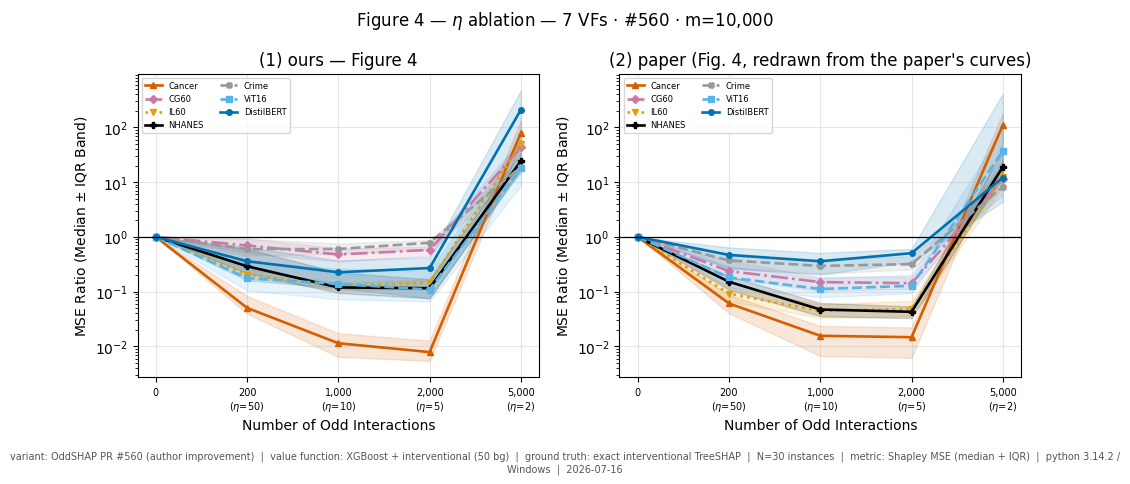

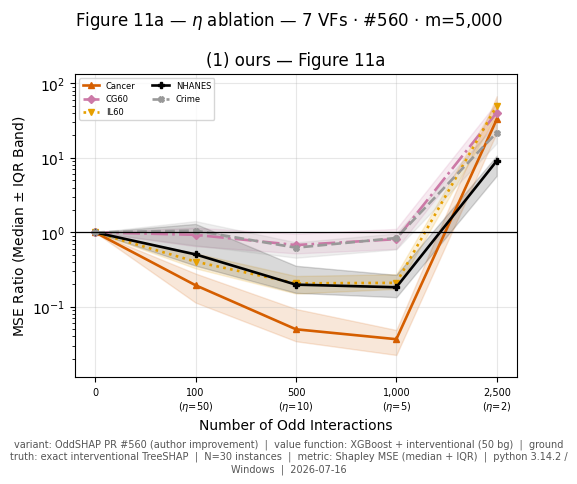

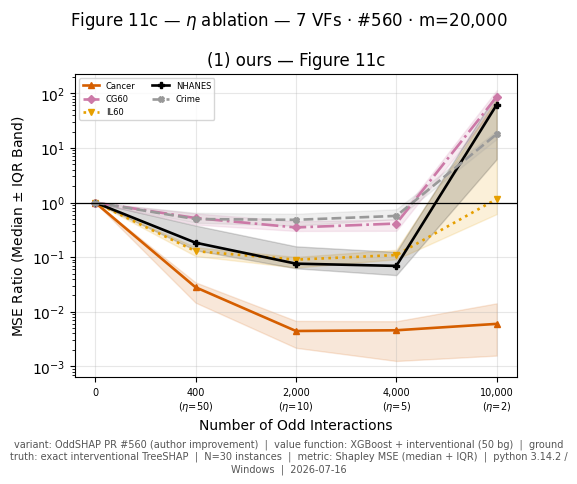

In [5]:
import math

_ETAS4 = [50, 10, 5, 2]  # eta values (interaction sparsity)
XPOS4 = list(range(5))  # evenly-spaced categorical x positions
VFS4 = [vf for vf in TAB_VFS + GPU_VFS if vf != "realestate"]  # Estate excluded, as in the paper


def _fig4_xlabels(budget):
    # 0 interactions (baseline), then ceil(m/eta) for each eta — the paper's own x labels
    return ["0"] + [f"{math.ceil(budget / e):,}\n($\\eta$={e})" for e in _ETAS4]


for budget, label in [(10_000, "Figure 4"), (5_000, "Figure 11a"), (20_000, "Figure 11c")]:
    paper4 = (
        R.load_paper_fig4(VFS4) if budget == 10_000 else None
    )  # paper panel only for Fig 4 (m=10000)
    ncol = 2 if paper4 else 1
    fig, axes = plt.subplots(1, ncol, figsize=(5.7 * ncol, 4.6), squeeze=False)
    xlab = _fig4_xlabels(budget)
    allv = []

    # (1) ours — MSE ratio vs the interaction-free baseline, one line per value function
    ax = axes[0][0]
    any_pts = False
    for vf in VFS4:
        pts = R.load_eta(
            vf, VARIANT, budget
        )  # [(n_int, ratio_med, ratio_q1, ratio_q3)] for eta 50,10,5,2
        if not pts:
            continue
        any_pts = True
        med = [1.0] + [p[1] for p in pts]  # position 0 = interaction-free baseline (ratio = 1)
        q1 = [1.0] + [p[2] for p in pts]
        q3 = [1.0] + [p[3] for p in pts]
        st = R.paper_vf_style(vf)  # colours aligned to the paper's Fig. 4 legend
        ax.plot(XPOS4, med, label=R.vf_display(vf), **st)
        ax.fill_between(XPOS4, q1, q3, color=st["color"], alpha=0.15)
        allv += [v for v in med + q1 + q3 if v > 0]
    if not any_pts:
        plt.close(fig)
        continue

    # (2) paper — the paper's Figure 4 redrawn from the digitised curves onto identical axes
    panels = [(ax, f"(1) ours — {label}")]
    if paper4:
        axp = axes[0][1]
        for vf in VFS4:
            curve = paper4.get(vf)
            if not curve:
                continue
            med = [c[2] for c in curve]
            q1 = [c[3] for c in curve]
            q3 = [c[4] for c in curve]
            med[0] = q1[0] = q3[0] = 1.0  # snap baseline to exactly 1.0
            st = R.paper_vf_style(vf)
            axp.plot(XPOS4, med, label=R.vf_display(vf), **st)
            axp.fill_between(XPOS4, q1, q3, color=st["color"], alpha=0.15)
            allv += [v for v in med + q1 + q3 if v > 0]
        panels.append((axp, "(2) paper (Fig. 4, redrawn from the paper's curves)"))

    ylo, yhi = min(allv) / 2, max(allv) * 2  # shared y-limits so the two panels align exactly
    for a, ttl in panels:
        a.set_yscale("log")
        a.set_ylim(ylo, yhi)
        a.set_xticks(XPOS4)
        a.set_xticklabels(xlab, fontsize=7)
        a.axhline(1.0, color="black", lw=0.9)  # interaction-free baseline reference
        a.grid(True, alpha=0.3)
        a.set_xlabel("Number of Odd Interactions")
        a.set_ylabel("MSE Ratio (Median $\\pm$ IQR Band)")
        a.set_title(ttl)
        a.legend(fontsize=6, ncol=2)

    fig.suptitle(
        R.fig_title(f"{label} — $\\eta$ ablation", f"{len(VFS4)} VFs", VARIANT, f"m={budget:,}"),
        y=1.02,
    )
    R.add_banner(fig, BANNER_TAB)
    plt.show()

## Figure 5 — runtime vs budget

Wall-clock runtime (median) of each estimator vs budget. Reproduces the paper's claim
that OddSHAP ≈ RegressionMSR in cost.

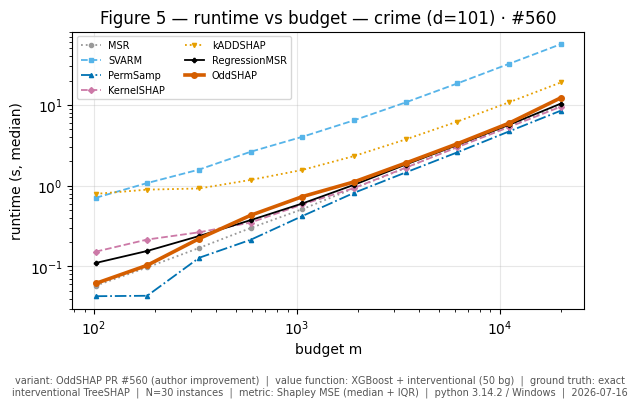

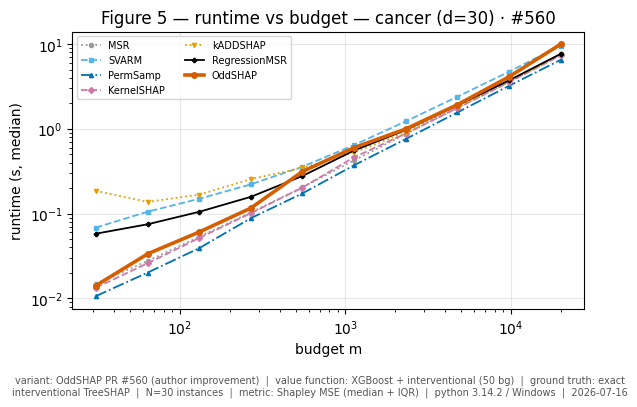

In [6]:
for vf in ["crime", "cancer"]:
    rt = R.load_runtime(vf, VARIANT)
    if not rt:
        continue
    fig, ax = plt.subplots(figsize=(6.6, 4.2))
    for e in ESTIMATORS:
        pts = rt.get(e, [])
        if pts:
            ax.plot([p[0] for p in pts], [p[1] for p in pts], label=e, **R.estimator_style(e))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("budget m")
    ax.set_ylabel("runtime (s, median)")
    ax.set_title(R.fig_title("Figure 5 — runtime vs budget", vf, VARIANT))
    ax.legend(fontsize=7, ncol=2)
    R.add_banner(fig, BANNER_TAB)
    plt.show()

## GPU value functions — ViT16, DistilBERT

Deep-learning value functions with exact Shapley ground truth (2^16 / 2^14 evaluations).

In [7]:
for vf in GPU_VFS:
    t = R.load_table1(vf, VARIANT)
    if not t:
        continue
    print(f"\n{vf} (d={R.PAPER_D[vf]}, exact GT, budget=100·d):")
    for rk, e in enumerate(sorted(t, key=lambda e: t[e][0]), 1):
        m, q1, q3, _, _ = t[e]
        tag = "  <- OddSHAP" if e == "OddSHAP" else ""
        print(f"  {rk}. {e:<14} {m:.2e}  [IQR {q1:.1e}, {q3:.1e}]{tag}")


vit16 (d=16, exact GT, budget=100·d):
  1. OddSHAP        1.15e-05  [IQR 5.3e-06, 1.7e-05]  <- OddSHAP
  2. RegressionMSR  1.35e-05  [IQR 7.0e-06, 2.6e-05]
  3. kADDSHAP       3.91e-05  [IQR 1.8e-05, 5.4e-05]
  4. SVARM          7.40e-05  [IQR 4.1e-05, 1.2e-04]
  5. KernelSHAP     8.99e-05  [IQR 5.3e-05, 1.3e-04]
  6. PermSamp       1.98e-04  [IQR 1.1e-04, 2.6e-04]
  7. MSR            6.09e-04  [IQR 2.4e-04, 8.7e-04]

distilbert (d=14, exact GT, budget=100·d):
  1. RegressionMSR  2.84e-05  [IQR 1.5e-05, 4.2e-05]
  2. OddSHAP        4.95e-05  [IQR 3.0e-05, 1.1e-04]  <- OddSHAP
  3. kADDSHAP       6.20e-05  [IQR 3.1e-05, 9.6e-05]
  4. KernelSHAP     1.37e-04  [IQR 6.9e-05, 4.1e-04]
  5. SVARM          1.65e-04  [IQR 2.4e-05, 3.6e-04]
  6. MSR            4.15e-04  [IQR 2.0e-04, 1.7e-03]
  7. PermSamp       8.59e-04  [IQR 4.2e-04, 1.2e-03]


## Summary

Using this OddSHAP variant, the reproduction recovers the paper's headline across the
value functions produced so far: OddSHAP's rank-1 average, the Figure-2 budget scaling,
the Figure-4/11 interaction-sparsity U-shape, and the Figure-5 runtime profile. Each
figure is annotated with the exact experimental environment that produced it, and uses a
colour-blind-safe palette with redundant marker/line-style encoding.